# 🧠 Machine Learning: Under the Hood

### The Math: `y = mx + b` (Linear Regression)
In biology, many features are strongly linearly connected. For example, if a certain protein concentration increases (`x`), the cell division rate increases (`y`). 
- **`y`** = The prediction (Cell division rate).
- **`x`** = The input data (Protein concentration).
- **`m`** = The "Weight" (How heavily the protein affects the cell).
- **`b`** = The "Bias" (The base division rate of the cell with zero protein).

When a Machine Learning model runs `.fit()`, it is not using AI magic. It is simply guessing `m` and `b` millions of times until it mathematically draws the perfect line of best fit through the biological data. 

To find the perfect line, the model uses **Calculus (Derivatives/Gradient Descent)** to calculate exactly how wrong its current guess is, and physically updates the `m` and `b` numbers to push the error closer to 0.


Final Model Found! m = 1.04, b = 0.61


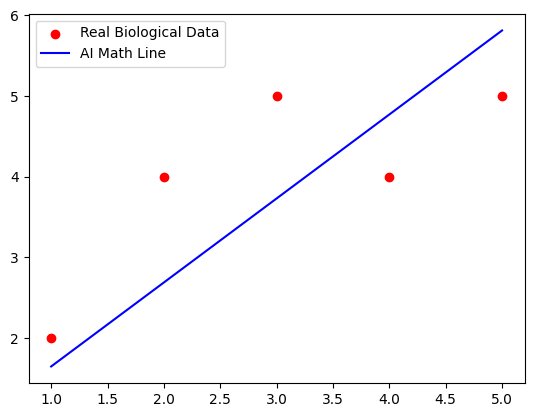

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# 1. The Fake Biological Data
X_protein = np.array([1, 2, 3, 4, 5]) # Protein concentration
Y_division = np.array([2, 4, 5, 4, 5]) # Cell division rate

# 2. The Machine Learning "Engine" Variables
m = 0.0 # The "Weight" (The model starts completely blind at 0)
b = 0.0 # The "Bias"
learning_rate = 0.01 # How big of a jump the AI makes when trying to fix its mistakes
epochs = 50 # Let it train 50 times

# 3. The Actual "Training" Loop (The Math) 
for i in range(epochs):
    # The AI makes a guess: y = mx + b
    Y_pred = m * X_protein + b 
    
    # How wrong was the guess? (This is Calculus / Derivatives)
    error = Y_division - Y_pred
    m_derivative = -(2/len(X_protein)) * sum(X_protein * error)
    b_derivative = -(2/len(X_protein)) * sum(error)
    
    # The AI corrects itself exactly based on the error
    m = m - (learning_rate * m_derivative)
    b = b - (learning_rate * b_derivative)

print(f"Final Model Found! m = {m:.2f}, b = {b:.2f}")

# 4. Let's draw the AI's final brain structure!
plt.scatter(X_protein, Y_division, color='red', label='Real Biological Data')
plt.plot(X_protein, (m * X_protein + b), color='blue', label='AI Math Line')
plt.legend()
plt.show()


In [12]:
from sklearn.linear_model import LinearRegression

# Force the flat list to become a vertical 2D column spreadsheet!
X_protein_2D = X_protein.reshape(-1, 1)

model = LinearRegression()
model.fit(X_protein_2D, Y_division)

print("Scikit-Learn's 'm' (Slope):", model.coef_[0])
print("Scikit-Learn's 'b' (Bias):", model.intercept_)



Scikit-Learn's 'm' (Slope): 0.6
Scikit-Learn's 'b' (Bias): 2.2


# 📍 K-Nearest Neighbors (KNN)

KNN is the simplest Machine Learning algorithm in existence because there is **no complex math or training involved at all.** 

It purely relies on the concept of "Guilt by Association."

**How it works:**
1. The AI plots every patient on a graph (e.g., Blood Pressure vs. Glucose).
2. A completely new, undiagnosed patient walks into the hospital.
3. The AI finds the **`K`** (a number you choose, like 5) patients who are physically closest to them on the graph.
4. If 4 of the 5 closest neighbors have Cancer, the AI votes that the new patient also has Cancer!
### The Fatal Flaw of KNN (K-Nearest Neighbors)
**It is incredibly slow on large datasets.** 
Because KNN has no "brain" or "memory," it does not actually train an upfront mathematical model. Instead, every single time a new, undiagnosed patient walks into the hospital, the hospital computer is physically forced to calculate the Pythagorean distance to **every single other patient** in the entire database just to find the closest 5 neighbors. 

If the hospital has 5 million cancer records, that requires massive, real-time computing power and will crash most laptops instantly!


In [13]:
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

# 1. Biological Data: [Blood Pressure, Glucose]
X_patients = np.array([
    [120, 90],  # Healthy
    [125, 85],  # Healthy
    [160, 140], # Sick
    [170, 150]  # Sick
])

# 2. Answers: 0 = Healthy, 1 = Sick
Y_diagnosis = np.array([0, 0, 1, 1])

# 3. Build the KNN Brain (Look at the 3 closest neighbors!)
knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_patients, Y_diagnosis)

# 4. A new patient arrives! 
# Their BP is 165, Glucose is 145. Are they Sick (1) or Healthy (0)?
new_patient = np.array([[165, 145]])
prediction = knn_model.predict(new_patient)

print(f"The KNN AI diagnosed the new patient with class: {prediction[0]}")


The KNN AI diagnosed the new patient with class: 1


# 📈 Logistic Regression (The King of Probabilities)

It takes `Linear Regression` (`y = mx + b`) and bends it into an `S-Curve` so the answer is always between `0.0` and `1.0`.

1. **If Math < 0.50:** The AI predicts Class 0 (Healthy).
2. **If Math >= 0.50:** The AI predicts Class 1 (Sick).
3. **The Superpower:** The exact decimal number tells the doctor how **confident** the AI is (e.g. `0.99` = 99% sure).

### The Fatal Flaw of Logistic Regression
**It can only draw a straight line.** 
Logistic Regression assumes the data can be perfectly split in half by one single, straight fence. 
If the biological data is highly complex and "curved" (for example, if a protein concentration causes cancer when it is *both* too low AND too high, but is healthy in the middle), Logistic Regression completely fails. It is mathematically impossible for its engine to separate that data with one single straight line! 


In [14]:
from sklearn.linear_model import LogisticRegression
import numpy as np

# 1. Biological Data: [Protein Level, Gene Activity]
X_patients = np.array([
    [1.1, 0.8], # Healthy
    [1.5, 0.9], # Healthy
    [4.0, 3.2], # Sick
    [4.5, 3.8]  # Sick
])

# 2. Answers: 0 = Healthy, 1 = Sick
Y_diagnosis = np.array([0, 0, 1, 1])

# 3. Build the S-Curve Math Engine
s_curve_model = LogisticRegression()
s_curve_model.fit(X_patients, Y_diagnosis)

# 4. A brand new patient arrives in the ER at 2am!
# Protein Level = 3.5, Gene Activity = 2.9 (Looks kind of sick...)
new_er_patient = np.array([[3.5, 2.9]])

# Standard Prediction (The hard 1 or 0)
base_diagnosis = s_curve_model.predict(new_er_patient)

# THE SUPERPOWER: Extracting the actual S-Curve Math Probabilities!
confidence_scores = s_curve_model.predict_proba(new_er_patient)

print(f"The AI's rigid diagnosis is: Class {base_diagnosis[0]}")
print(f"The AI is exactly {confidence_scores[0][1]*100:.1f}% confident that the patient has Class 1 (Sick).")


The AI's rigid diagnosis is: Class 1
The AI is exactly 73.6% confident that the patient has Class 1 (Sick).
